[*********************100%***********************]  1 of 1 completed


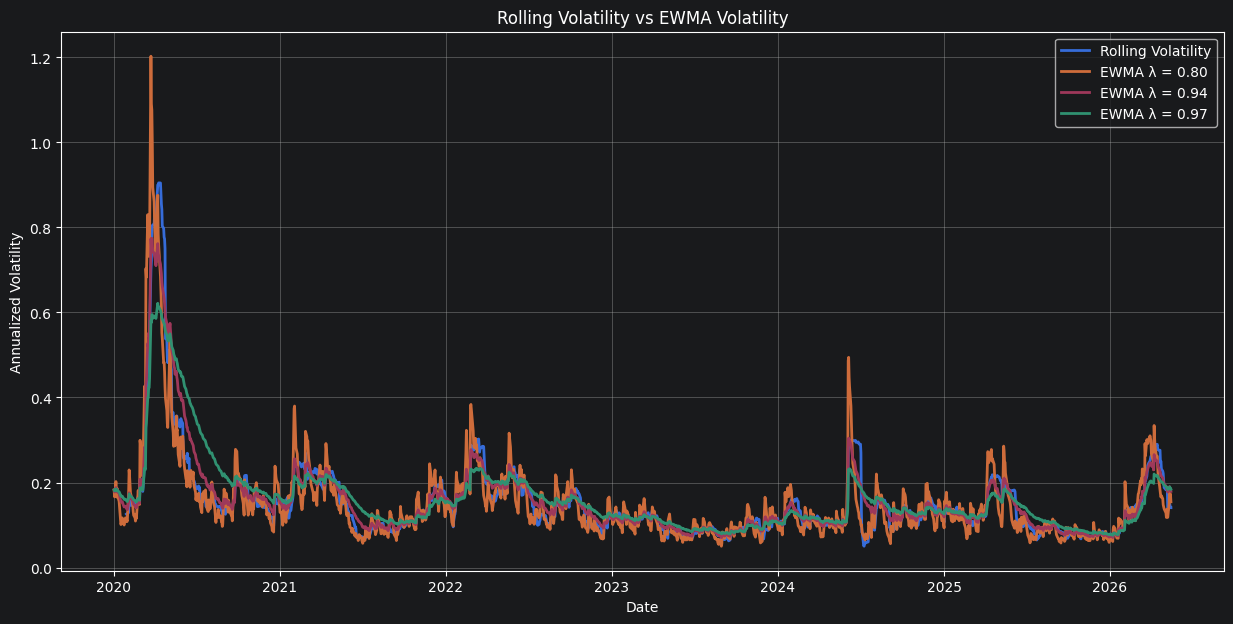

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Download NIFTY data
# -----------------------------------
df = yf.download("^NSEI", start="2020-01-01")

# -----------------------------------
# Calculate log returns
# -----------------------------------
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

# Remove NaN values
returns = df["log_return"].dropna()

# -----------------------------------
# EWMA Function
# -----------------------------------
def calculate_ewma(returns, lambda_):

    # Initial variance
    ewma_var = [returns.var()]

    # Recursive EWMA calculation
    for r in returns[1:]:

        new_var = (
            lambda_ * ewma_var[-1]
            + (1 - lambda_) * r**2
        )

        ewma_var.append(new_var)

    # Convert variance to annualized volatility
    ewma_vol = np.sqrt(ewma_var) * np.sqrt(252)

    return ewma_vol

# -----------------------------------
# Calculate EWMA Volatility
# -----------------------------------
ewma_080 = calculate_ewma(returns, 0.80)
ewma_094 = calculate_ewma(returns, 0.94)
ewma_097 = calculate_ewma(returns, 0.97)

# -----------------------------------
# Align dataframe
# -----------------------------------
df = df.iloc[1:].copy()

# Add results to dataframe
df["ewma_080"] = ewma_080
df["ewma_094"] = ewma_094
df["ewma_097"] = ewma_097

# -----------------------------------
# Rolling Volatility for comparison
# -----------------------------------
df["rolling_vol"] = (
    returns.rolling(20).std() * np.sqrt(252)
)

# -----------------------------------
# Plot Comparison
# -----------------------------------
plt.figure(figsize=(15,7))

plt.plot(
    df.index,
    df["rolling_vol"],
    label="Rolling Volatility",
    linewidth=2
)

plt.plot(
    df.index,
    df["ewma_080"],
    label="EWMA λ = 0.80",
    linewidth=2
)

plt.plot(
    df.index,
    df["ewma_094"],
    label="EWMA λ = 0.94",
    linewidth=2
)

plt.plot(
    df.index,
    df["ewma_097"],
    label="EWMA λ = 0.97",
    linewidth=2
)

# -----------------------------------
# Chart Styling
# -----------------------------------
plt.title("Rolling Volatility vs EWMA Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)

plt.show()